In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import os

In [3]:
os.chdir('C:\\Users\\SAURABH\\Downloads\\archive (7)')
df = pd.read_csv('cleaned.csv')

In [4]:
df.head()

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,quantity,unit_price,order_id,order_date,order_status,payment_method,rating,review_text,full_name,total_amt
0,CUST2353,Erica,Oliver,Female,Teenagers,2022-06-29,Canada,PROD108,Fitbit Versa 3,Electronics,3,229,ORD10000,2023-07-13,Pending,Credit Card,2,good,Erica Oliver,687
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,4,59,ORD10001,2024-08-12,Pending,PayPal,2,average,Christopher White,236
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,2,59,ORD10002,2024-08-04,Delivered,Cash on Delivery,5,good,Spencer Foster,118
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,4,399,ORD10003,2025-05-23,Delivered,Cash on Delivery,2,very good,Jessica Harris,1596
4,CUST1296,Amy,Johnson,Female,Teenagers,2021-03-23,Brazil,PROD105,Adidas Running Shoes,Apparel,1,110,ORD10004,2023-07-02,Returned,Cash on Delivery,1,very good,Amy Johnson,110


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9598 entries, 0 to 9597
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     9598 non-null   object
 1   first_name      9598 non-null   object
 2   last_name       9598 non-null   object
 3   gender          9598 non-null   object
 4   age_group       9598 non-null   object
 5   signup_date     9598 non-null   object
 6   country         9598 non-null   object
 7   product_id      9598 non-null   object
 8   product_name    9598 non-null   object
 9   category        9598 non-null   object
 10  quantity        9598 non-null   int64 
 11  unit_price      9598 non-null   int64 
 12  order_id        9598 non-null   object
 13  order_date      9598 non-null   object
 14  order_status    9598 non-null   object
 15  payment_method  9598 non-null   object
 16  rating          9598 non-null   int64 
 17  review_text     9598 non-null   object
 18  full_nam

In [6]:
df.isnull().sum()

customer_id       0
first_name        0
last_name         0
gender            0
age_group         0
signup_date       0
country           0
product_id        0
product_name      0
category          0
quantity          0
unit_price        0
order_id          0
order_date        0
order_status      0
payment_method    0
rating            0
review_text       0
full_name         0
total_amt         0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,9598.0,2.932278,1.401408,1.0,2.0,3.0,4.0,5.0
unit_price,9598.0,216.511148,246.018123,25.0,80.0,129.0,199.0,999.0
rating,9598.0,2.993228,1.408771,1.0,2.0,3.0,4.0,5.0
total_amt,9598.0,589.146385,675.350638,25.0,198.0,387.0,687.0,3596.0


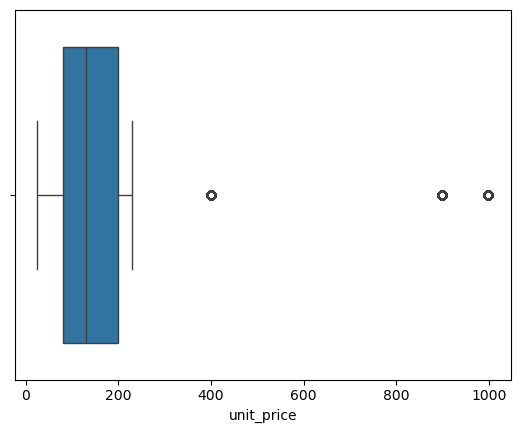

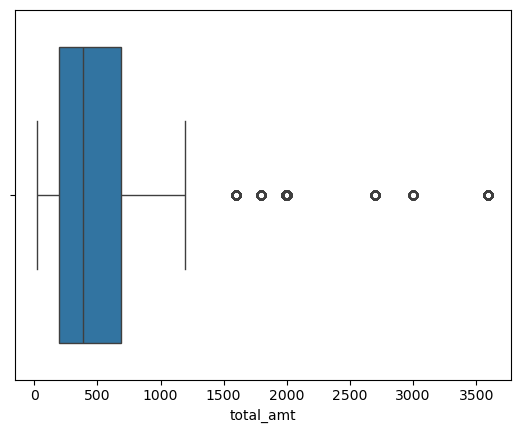

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['unit_price','total_amt']:
    sns.boxplot(data=df, x=col)
    plt.show()

In [9]:
from scipy import stats
import numpy as np

In [10]:
z_score = np.abs(stats.zscore(df[['unit_price','total_amt']]))

In [11]:
df['outliers'] = (z_score > 3).any(axis=1)

In [12]:
outliers = df[df['outliers']].drop(columns=['outliers'])
cleaned = df[~df['outliers']].drop(columns=['outliers'])

In [13]:
cleaned.head()

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,quantity,unit_price,order_id,order_date,order_status,payment_method,rating,review_text,full_name,total_amt
0,CUST2353,Erica,Oliver,Female,Teenagers,2022-06-29,Canada,PROD108,Fitbit Versa 3,Electronics,3,229,ORD10000,2023-07-13,Pending,Credit Card,2,good,Erica Oliver,687
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,4,59,ORD10001,2024-08-12,Pending,PayPal,2,average,Christopher White,236
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,2,59,ORD10002,2024-08-04,Delivered,Cash on Delivery,5,good,Spencer Foster,118
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,4,399,ORD10003,2025-05-23,Delivered,Cash on Delivery,2,very good,Jessica Harris,1596
4,CUST1296,Amy,Johnson,Female,Teenagers,2021-03-23,Brazil,PROD105,Adidas Running Shoes,Apparel,1,110,ORD10004,2023-07-02,Returned,Cash on Delivery,1,very good,Amy Johnson,110


In [14]:
cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,8973.0,2.954419,1.419184,1.0,2.0,3.0,4.0,5.0
unit_price,8973.0,165.017163,154.418661,25.0,80.0,120.0,199.0,899.0
rating,8973.0,2.996545,1.408246,1.0,2.0,3.0,4.0,5.0
total_amt,8973.0,458.905717,408.985151,25.0,177.0,330.0,597.0,1995.0


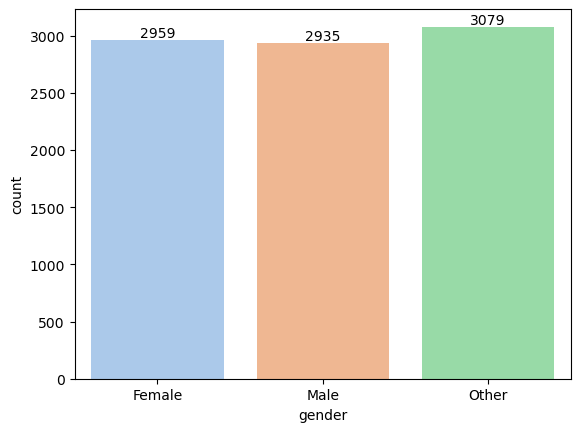

In [15]:
ax = sns.countplot(x='gender',data=cleaned,palette='pastel')
for bar in ax.containers:
    ax.bar_label(bar)

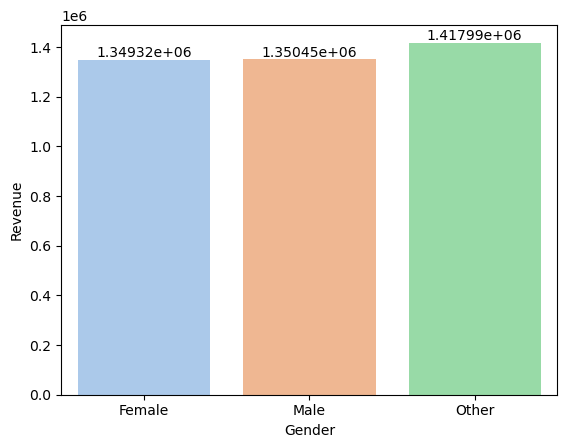

In [16]:
ax = cleaned[['gender','total_amt']].groupby('gender').sum()
bx = sns.barplot(data=ax, x='gender',y='total_amt',palette='pastel')
plt.xlabel('Gender')
plt.ylabel('Revenue')
for bar in bx.containers:
    bx.bar_label(bar)

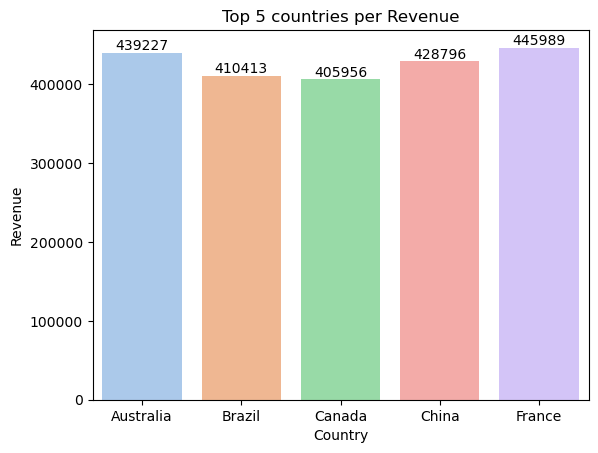

In [17]:
ax = cleaned[['country','total_amt']].groupby('country').sum().head(5)
bx = sns.barplot(data=ax,x='country',y='total_amt',palette='pastel')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.title('Top 5 countries per Revenue')
for bar in bx.containers:
    bx.bar_label(bar)

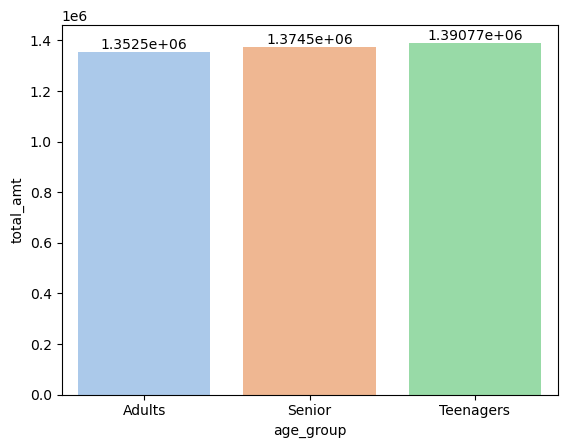

In [18]:
ax = cleaned[['age_group','total_amt']].groupby('age_group').sum().round()
bx = sns.barplot(data=ax,x='age_group',y='total_amt',palette='pastel')
for bar in bx.containers:
    bx.bar_label(bar)

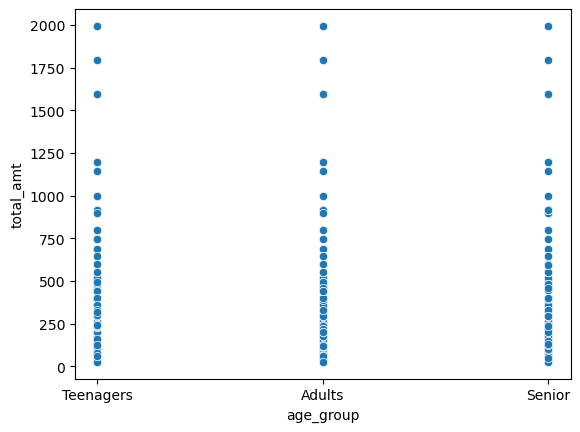

In [19]:
sns.scatterplot(data=cleaned,x='age_group',y='total_amt')
plt.show()

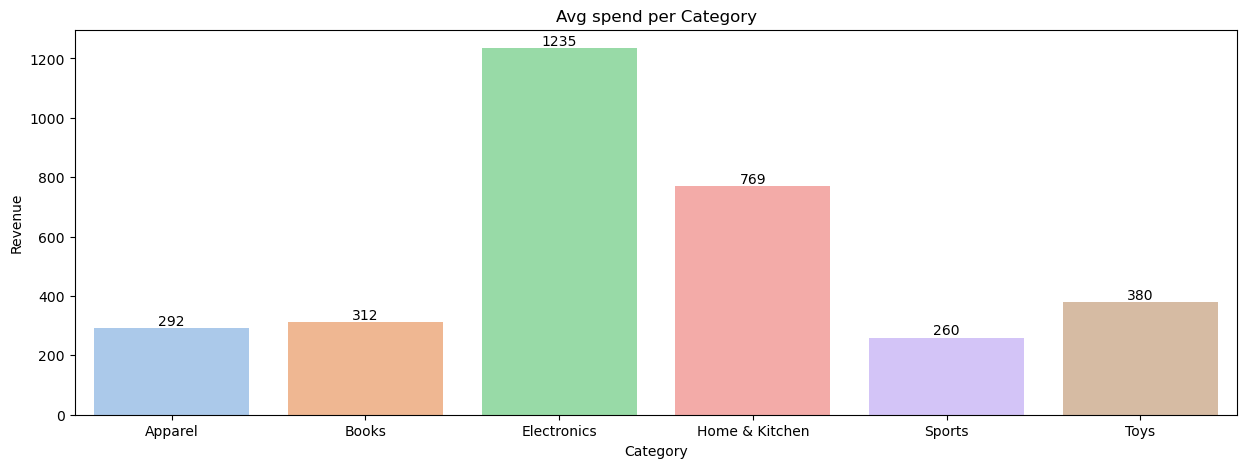

In [20]:
ax = df[['category','total_amt']].groupby('category').mean().round()
plt.figure(figsize=(15,5))
bx = sns.barplot(data=ax,x='category',y='total_amt',palette='pastel')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Avg spend per Category')
for bar in bx.containers:
    bx.bar_label(bar)

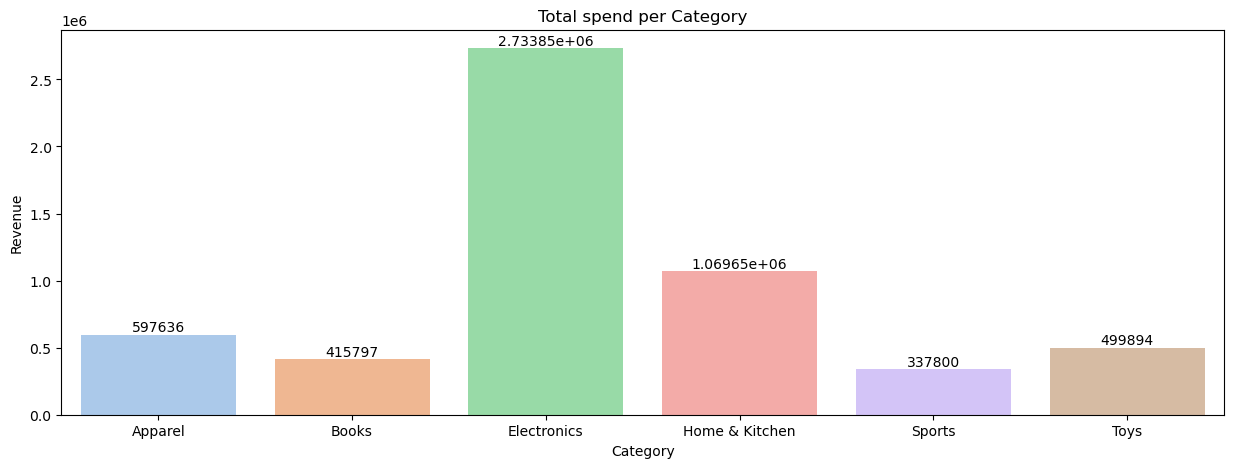

In [21]:
ax = df[['category','total_amt']].groupby('category').sum().round()
plt.figure(figsize=(15,5))
bx = sns.barplot(data=ax,x='category',y='total_amt',palette='pastel')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Total spend per Category')
for bar in bx.containers:
    bx.bar_label(bar)

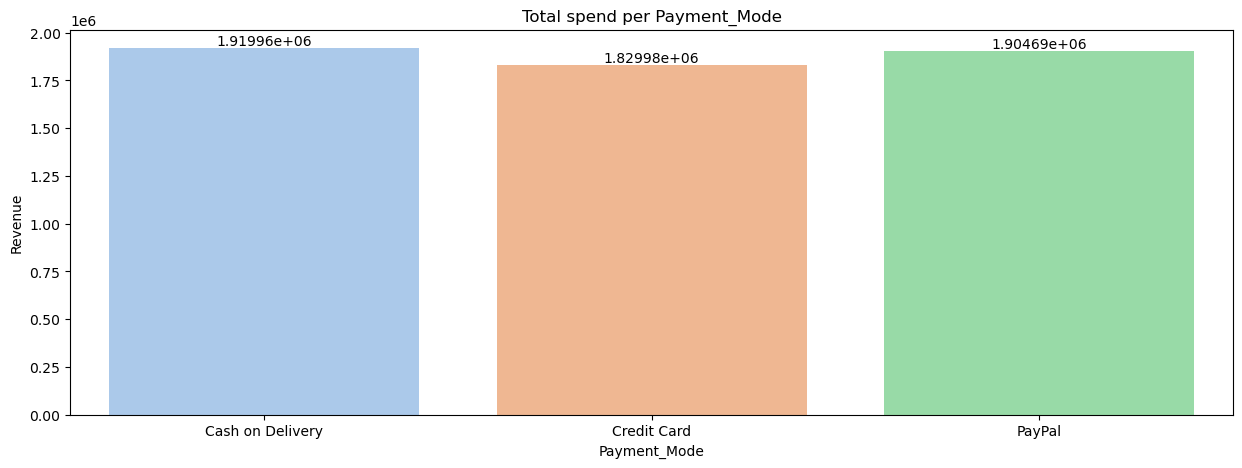

In [22]:
ax = df[['payment_method','total_amt']].groupby('payment_method').sum().round()
plt.figure(figsize=(15,5))
bx = sns.barplot(data=ax,x='payment_method',y='total_amt',palette='pastel')
plt.xlabel('Payment_Mode')
plt.ylabel('Revenue')
plt.title('Total spend per Payment_Mode')
for bar in bx.containers:
    bx.bar_label(bar)

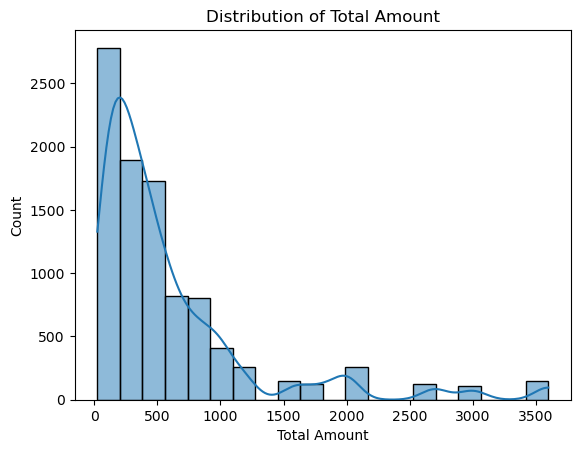

In [39]:
sns.histplot(df['total_amt'], bins=20, kde=True)
plt.xlabel('Total Amount')
plt.title('Distribution of Total Amount')
plt.show()

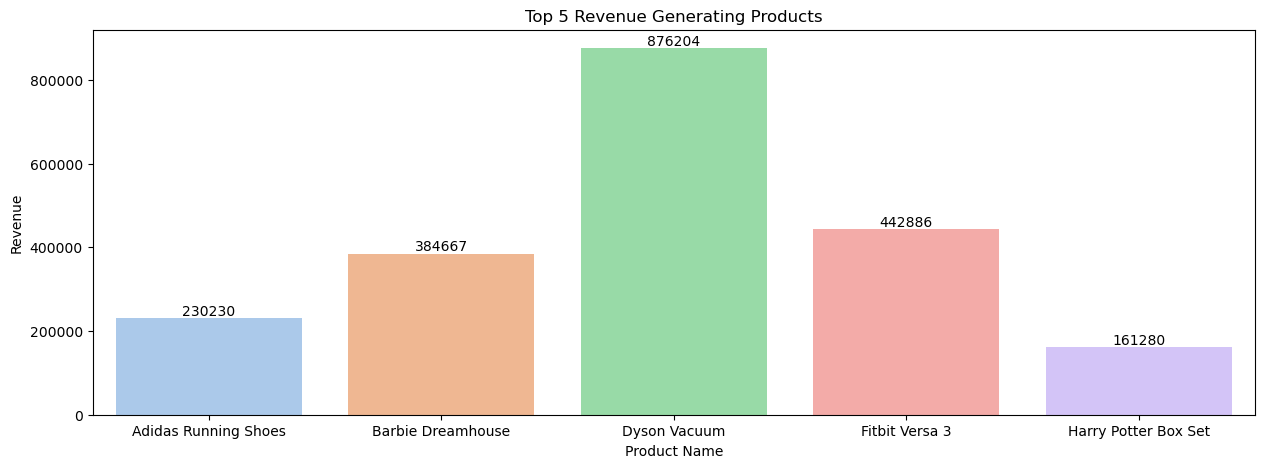

In [35]:
ax = cleaned[['product_name','total_amt']].groupby('product_name').sum().round().head(5)
plt.figure(figsize=(15,5))
bx = sns.barplot(data=ax,x='product_name',y='total_amt',palette='pastel')
plt.xlabel('Product Name')
plt.ylabel('Revenue')
plt.title('Top 5 Revenue Generating Products')
for bar in bx.containers:
    bx.bar_label(bar)

In [36]:
df['total_amt'].skew()

np.float64(2.5039986238240064)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [25]:
X = cleaned[['quantity','unit_price']]
y = cleaned['total_amt']

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 4)
regr = LinearRegression()
regr.fit(X_train,y_train)
pred = regr.predict(X_test)

In [27]:
pred

array([380.73028774, 534.50410409, 655.81474173, ..., 226.95647139,
       688.27792045, 541.799385  ], shape=(2692,))

In [28]:
regr.score(X_test,y_test)

0.7922363528359054